In [44]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import shap
import joblib

from sklearn.model_selection import train_test_split

from src.preprocess import load_data, clean_data, encode_features

In [45]:
df = load_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded ✓")
df.head()

Dataset loaded ✓


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df = clean_data(df)

df = encode_features(df)

print("Data preprocessing complete ✓")

Data preprocessing complete ✓


In [53]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature shape:", X.shape)

Feature shape: (7032, 19)


In [56]:
df = load_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = clean_data(df)

df = encode_features(df)

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Remove any remaining NaN rows
mask = y.notna()
X = X[mask]
y = y[mask]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [58]:
# Encode categorical features
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Ensure same columns as training data
X_test_encoded = X_test_encoded.reindex(columns=X.columns, fill_value=0)

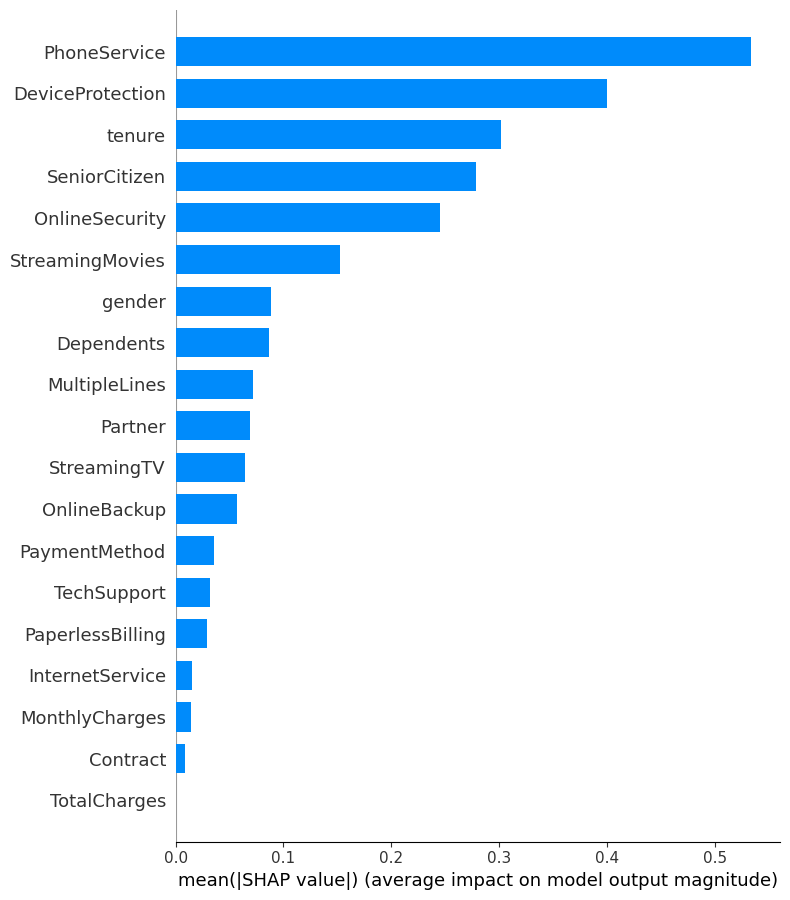

In [61]:
import numpy as np

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test, check_additivity=False)

shap.summary_plot(
    np.array(shap_values),
    X_test,
    plot_type="bar",
    feature_names=X.columns.tolist()
)